# Simulation of Vessel Trajectories & Anomalies

Use the config file to adjust the number of vessels, obstacles, speed limits, ...

16

In [8]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=config["num_ships"],
        max_speed_range=config["max_speed_range"],
        speed_variation=config["speed_variation"],
        directional_variation=config["directional_variation"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=config["obstacles"],
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"]
    )

for type, agents in model.agents_by_type.items():
    print(f'{type}: {len(agents)}')

for ship in model.agents.select(agent_type=Ship):
    print(f"Ship {ship.unique_id} has a maximum speed of {ship.original_max_speed}.")

<class 'agents.obstacle.Obstacle'>: 3
<class 'agents.port.Port'>: 10
<class 'agents.ship.Ship'>: 50
Ship 0 has a maximum speed of 5.095199525691372.
Ship 1 has a maximum speed of 7.626902743997075.
Ship 2 has a maximum speed of 4.46772298221387.
Ship 3 has a maximum speed of 3.5747439611990055.
Ship 4 has a maximum speed of 4.439817024256222.
Ship 5 has a maximum speed of 9.663720728627787.
Ship 6 has a maximum speed of 6.645273084303042.
Ship 7 has a maximum speed of 8.259876658452477.
Ship 8 has a maximum speed of 6.162136990179145.
Ship 9 has a maximum speed of 7.287853477126474.
Ship 10 has a maximum speed of 4.971261170065851.
Ship 11 has a maximum speed of 5.810710449285798.
Ship 12 has a maximum speed of 5.348585846758955.
Ship 13 has a maximum speed of 8.50051926565732.
Ship 14 has a maximum speed of 4.5446695422859875.
Ship 15 has a maximum speed of 4.148865946566119.
Ship 16 has a maximum speed of 3.406618085621491.
Ship 17 has a maximum speed of 7.5840316273973745.
Ship 18 h

## Trajectory Simulation

In [9]:
t0 = datetime.now()
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
t1 = datetime.now()
print(f"{datetime.now()} Finished in {t1-t0}.")

2025-09-11 11:44:48.552119 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
2025-09-11 11:54:01.246410 Finished in 0:09:12.694241.


In [3]:
model.datacollector.get_agent_vars_dataframe()

x  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.port.Port object at 0x7f6b1de6f370>                NaN   
     <agents.port.Port object at 0x7f6b1de6f490>                NaN   
...                                                             ...   
3600 40                                                   42.861479   
     41                                                  357.160670   
     19                                                  473.431239   
     33                                                  590.964712   
     44                                                  339.494353   

                                                                  y  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...         NaN   
     <agents.port.Port object at 0x7f6b1de6f370>                NaN   
     <agents.port.Port object at 0x7f6b1de6f490>                NaN   
...                                                             ...   
3600 40                                                  187.916986   
     41                                                  353.082096   
     19                                                  191.061328   
     33                                                  241.142724   
     44                                                  329.795929   

                                                                                                 AStarPath  
Step AgentID                                                                                                
0    <agents.obstacle.Obstacle object at 0x7f6b1de6f...                                               None  
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...                                               None  
     <agents.obstacle.Obstacle object at 0x7f6b1de6f...                                               None  
     <agents.port.Port object at 0x7f6b1de6f370>                                                      None  
     <agents.port.Port object at 0x7f6b1de6f490>                                                      None  
...                                                                                                    ...  
3600 40                                                  [(10, 39), (11, 40), (11, 41), (11, 42), (11, ...  
     41                                                  [(442, 425), (441, 424), (440, 423), (439, 422...  
     19                                                  [(591, 241), (590, 241), (589, 241), (588, 241...  
     33                                                  [(554, 258), (555, 257), (556, 257), (557, 256...  
     44                                                  [(442, 425), (441, 424), (440, 423), (439, 422...  

[226863 rows x 3 columns]

In [4]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,103.794837,156.070802,"[(103, 156), (104, 157), (105, 158), (106, 159..."
1,0,1,349.579294,424.369819,"[(349, 424), (349, 423), (349, 422), (349, 421..."
2,0,2,10.920191,39.770506,"[(10, 39), (11, 40), (11, 41), (11, 42), (11, ..."
3,0,3,470.305509,238.523290,"[(470, 238), (469, 237), (469, 236), (468, 235..."
4,0,4,349.579294,424.369819,"[(349, 424), (349, 423), (349, 422), (349, 421..."
...,...,...,...,...,...
180045,3600,40,42.861479,187.916986,"[(10, 39), (11, 40), (11, 41), (11, 42), (11, ..."
180046,3600,41,357.160670,353.082096,"[(442, 425), (441, 424), (440, 423), (439, 422..."
180047,3600,19,473.431239,191.061328,"[(591, 241), (590, 241), (589, 241), (588, 241..."
180048,3600,33,590.964712,241.142724,"[(554, 258), (555, 257), (556, 257), (557, 256..."


Saved simulation plot to simulation_plot.png


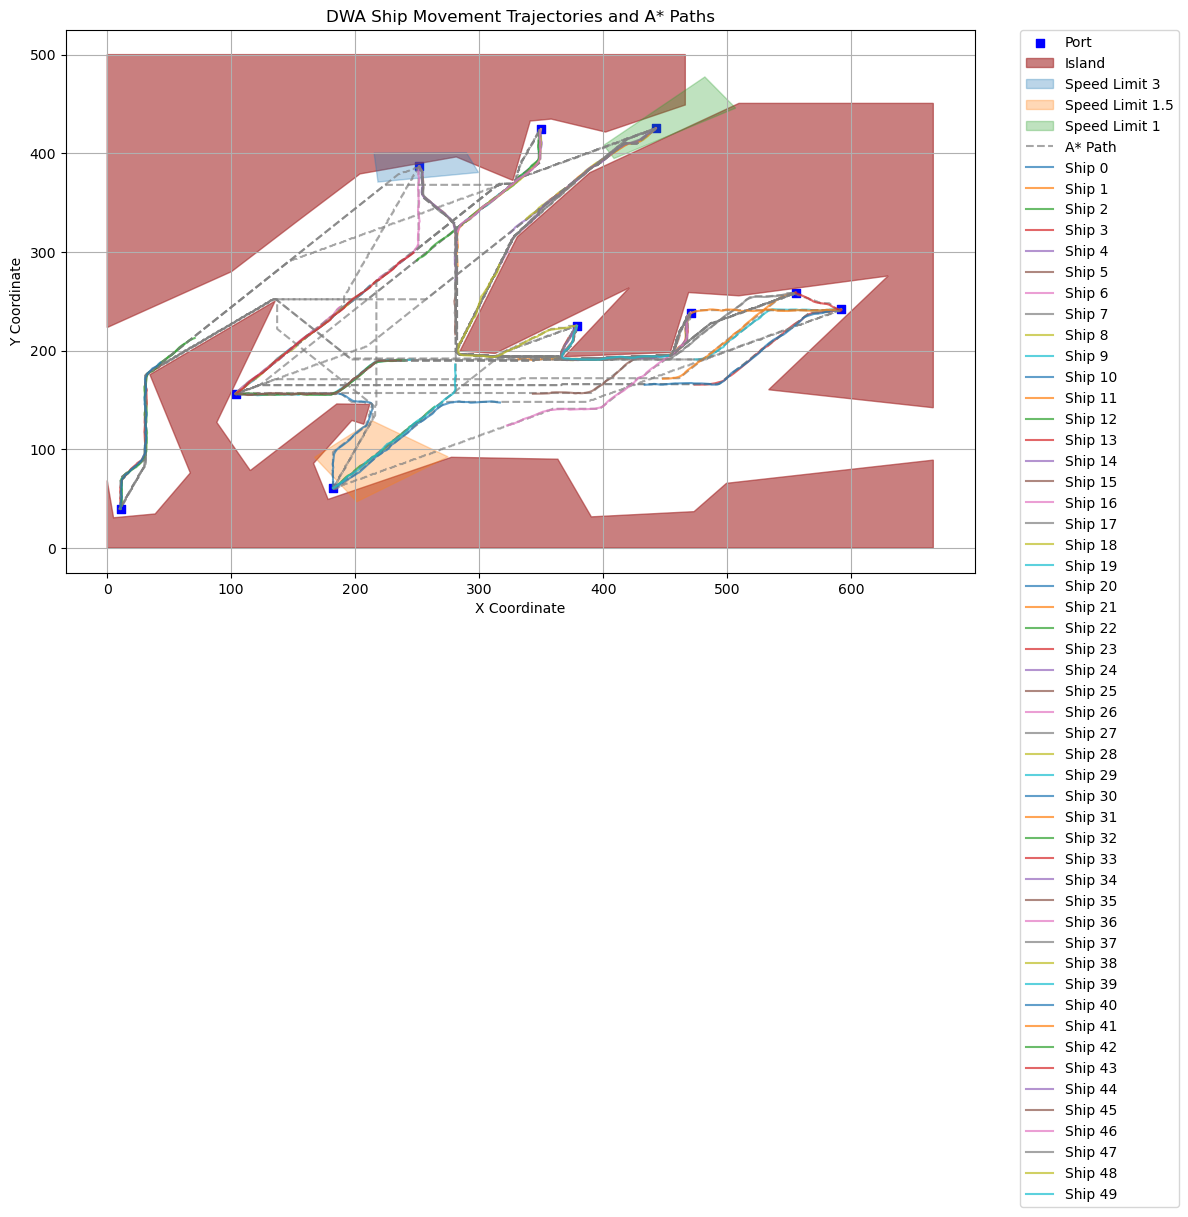

In [5]:
from visualization import plot_simulation

# Run visualization
plot_simulation(df, config)

### Transform Grid to Real-World coordinates

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


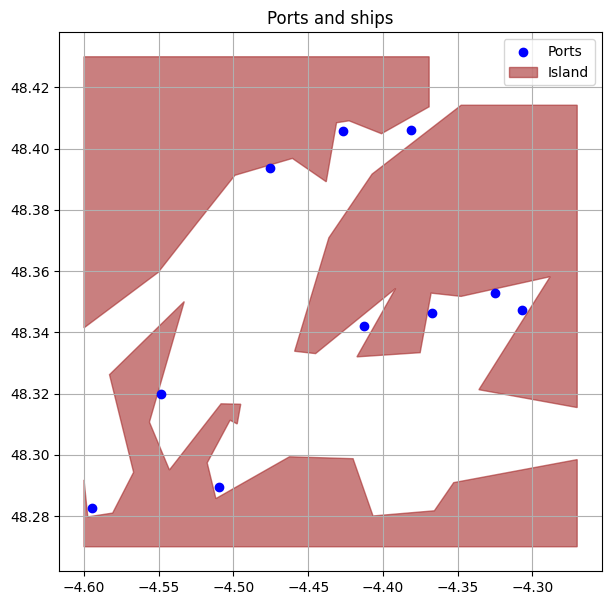

In [6]:
import movingpandas as mpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

start_datetime = datetime.now()
#df = df.drop('AStarPath', axis=1)

def map_to_geocoords(x, y, bounds, width, height):
    lon = bounds["min_lon"] + (x / width) * (bounds["max_lon"] - bounds["min_lon"])
    lat = bounds["min_lat"] + (y / height) * (bounds["max_lat"] - bounds["min_lat"])
    return lon, lat

df[["x", "y"]] = df.apply(
    lambda row: map_to_geocoords(row["x"], row["y"], config["geospatial_bounds"], config["width"], config["height"]),
    axis=1, result_type="expand"
)

time_step_seconds = config["time_step_seconds"]
start_datetime = datetime.now()

df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step * time_step_seconds))

tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

fig, ax = plt.subplots(figsize=(7,7))

# Transform and plot ports
geo_ports = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in config["ports"]]
x_coords, y_coords = zip(*geo_ports)
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

# Transform and plot obstacles
for island in config["obstacles"]:
    geo_island = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in island]
    island_shape = Polygon(geo_island)
    x, y = island_shape.exterior.xy
    ax.fill(x,y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")



ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()


In [7]:
import movingpandas as mpd

start_datetime = datetime.now()
df = df.drop('AStarPath', axis=1, errors='ignore'
)
df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=4326)

In [8]:
#tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)
tc

TrajectoryCollection with 50 trajectories

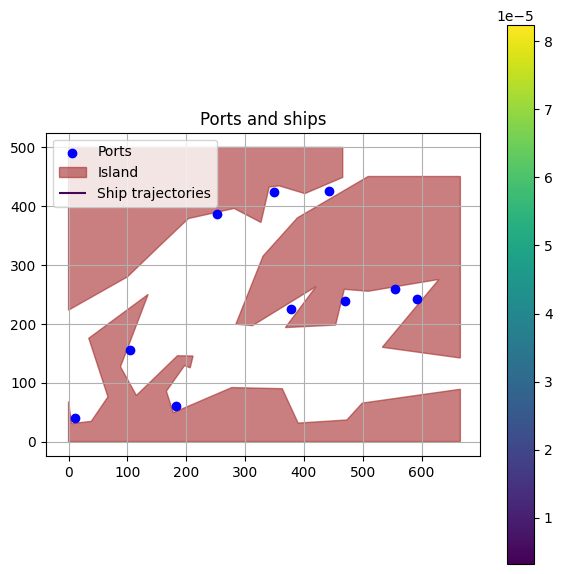

In [9]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

fig, ax = plt.subplots(figsize=(7,7))

x_coords, y_coords = zip(*config["ports"])
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

for island in config["obstacles"]:
    island_shape = Polygon(island)
    x, y = island_shape.exterior.xy
    ax.fill(x, y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")

tc.plot(ax=ax, label='Ship trajectories', column='speed', legend=True)
ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()

In [10]:
try:
    tc.trajectories[0].hvplot()
except:
    pass

In [11]:
import os

tc.add_speed(overwrite=True, n_threads=os.cpu_count())
tc.trajectories[0].df#.hvplot(c='speed')

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Miss

,Step,AgentID,geometry,speed
t,,,,
2025-09-04 15:40:23.865360,0,0,POINT (-4.367 48.346),0.000004
2025-09-04 15:40:24.865360,1,0,POINT (-4.367 48.346),0.000004
2025-09-04 15:40:25.865360,2,0,POINT (-4.367 48.346),0.000005
2025-09-04 15:40:26.865360,3,0,POINT (-4.367 48.346),0.000005
2025-09-04 15:40:27.865360,4,0,POINT (-4.367 48.346),0.000006
...,...,...,...,...
2025-09-04 16:40:19.865360,3596,0,POINT (-4.307 48.347),0.000005
2025-09-04 16:40:20.865360,3597,0,POINT (-4.307 48.347),0.000005
2025-09-04 16:40:21.865360,3598,0,POINT (-4.307 48.347),0.000005


In [12]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')
sim_result#[sim_result['speed'] > 0.6]

Saved simulation results to sim_20250904_154120.csv


,Step,AgentID,geometry,speed,x,y
t,,,,,,
2025-09-04 15:40:23.865360,0,0,POINT (-4.367 48.346),0.000004,-4.366966,48.346327
2025-09-04 15:40:24.865360,1,0,POINT (-4.367 48.346),0.000004,-4.366962,48.346326
2025-09-04 15:40:25.865360,2,0,POINT (-4.367 48.346),0.000005,-4.366957,48.346324
2025-09-04 15:40:26.865360,3,0,POINT (-4.367 48.346),0.000005,-4.366952,48.346321
2025-09-04 15:40:27.865360,4,0,POINT (-4.367 48.346),0.000006,-4.366947,48.346319
...,...,...,...,...,...,...
2025-09-04 16:40:19.865360,3596,49,POINT (-4.365 48.331),0.000016,-4.364640,48.331151
2025-09-04 16:40:20.865360,3597,49,POINT (-4.365 48.331),0.000016,-4.364656,48.331148
2025-09-04 16:40:21.865360,3598,49,POINT (-4.365 48.331),0.000017,-4.364672,48.331146


## Anomaly Simulation

In [1]:
import numpy as np
import pandas as pd
import movingpandas as mpd
from datetime import datetime, timedelta

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/pyproj/__init__.py:95: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


In [2]:
sim_out_file_name = 'sim_20250904_154120.csv'
PERCENTAGE_OF_ANOMALIES = 0.05

In [3]:
sims = pd.read_csv(sim_out_file_name)
sims

,t,Step,AgentID,geometry,speed,x,y
0,2025-09-04 15:40:23.865360,0,0,POINT (-4.366965738783783 48.346327452800004),0.000004,-4.366966,48.346327
1,2025-09-04 15:40:24.865360,1,0,POINT (-4.366961781453443 48.34632552710109),0.000004,-4.366962,48.346326
2,2025-09-04 15:40:25.865360,2,0,POINT (-4.366957262695056 48.34632355886671),0.000005,-4.366957,48.346324
3,2025-09-04 15:40:26.865360,3,0,POINT (-4.3669522477986575 48.346321495774546),0.000005,-4.366952,48.346321
4,2025-09-04 15:40:27.865360,4,0,POINT (-4.366946726263988 48.34631935336846),0.000006,-4.366947,48.346319
...,...,...,...,...,...,...,...
180045,2025-09-04 16:40:19.865360,3596,49,POINT (-4.3646398771291555 48.33115093986692),0.000016,-4.364640,48.331151
180046,2025-09-04 16:40:20.865360,3597,49,POINT (-4.364655750976666 48.33114840650928),0.000016,-4.364656,48.331148
180047,2025-09-04 16:40:21.865360,3598,49,POINT (-4.364672206041691 48.33114607376575),0.000017,-4.364672,48.331146
180048,2025-09-04 16:40:22.865360,3599,49,POINT (-4.364689236608698 48.33114395959875),0.000017,-4.364689,48.331144


In [4]:
#sims = sims[sims.AgentID<29].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'


In [5]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import movingpandas as mpd
from pyproj import CRS, Transformer



# Assure-toi que 't' est bien en datetime
sims = sims.copy()
sims['t'] = pd.to_datetime(sims['t'])

crs_wgs84  = CRS.from_string("+proj=longlat +datum=WGS84 +no_defs +type=crs")


# 1) Créer la colonne geometry à partir de x,y
sims_gdf = gpd.GeoDataFrame(
    sims,
    geometry=gpd.points_from_xy(sims['x'], sims['y']),
    crs=crs_wgs84

   # Maintenant OK, car geometry est définie
)

# 2) Trier par AgentID et temps (bonnes pratiques)
sims_gdf = sims_gdf.sort_values(['AgentID', 't'])

# 3) Créer la TrajectoryCollection (plus besoin de x,y ici)
tc = mpd.TrajectoryCollection(sims_gdf, traj_id_col='AgentID', t='t')


tc

TrajectoryCollection with 50 trajectories

In [6]:
# Remove stopped segments (with speed < 0.0001)
#tc = mpd.SpeedSplitter(tc).split(speed=0.0001, duration=timedelta(seconds=5))
tc

TrajectoryCollection with 50 trajectories

### Speed

Change the timestamps to make a subsection of the trajectory faster

In [7]:
unique_ids = sims.AgentID.unique()
unique_ids

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [8]:
sample_ids_pd = pd.Series(unique_ids).sample(frac=PERCENTAGE_OF_ANOMALIES).tolist()
print("Subset we'll insert anomalies in: ", sample_ids_pd)

Subset we'll insert anomalies in:  [43, 5]


In [9]:
def inject_speed_anomaly(traj, duration_pct=(0.1,0.2), speedup_pct=(1.5,2.5)):
    df = traj.df.copy()
    df.reset_index(inplace=True)
    df["t_diff"] = df['t'].diff()
    # Choose within middle range
    total_steps = len(df)
    anomaly_start_idx = np.random.randint(0.1 * total_steps, 0.8 * total_steps)  
    duration_pct = duration_pct[0] + (np.random.random() * (duration_pct[1]-duration_pct[0]))
    anomaly_duration = int(duration_pct * total_steps)  
    # Insert new values
    speedup_pct = speedup_pct[0] + (np.random.random() * (speedup_pct[1]-speedup_pct[0]))
    new_vals = df.iloc[anomaly_start_idx : anomaly_start_idx + anomaly_duration].t_diff / speedup_pct
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "t_diff"] = new_vals
    # Flag anomalies
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "is_anomaly"] = True
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "anomaly_type"] = 'speed'

    # Correct the timestamp update logic
    df["t"] = df["t"].iloc[0] + df["t_diff"].fillna(pd.Timedelta(seconds=0)).cumsum()
    return mpd.Trajectory(df,t='t',traj_id=traj.id)

<Axes: >

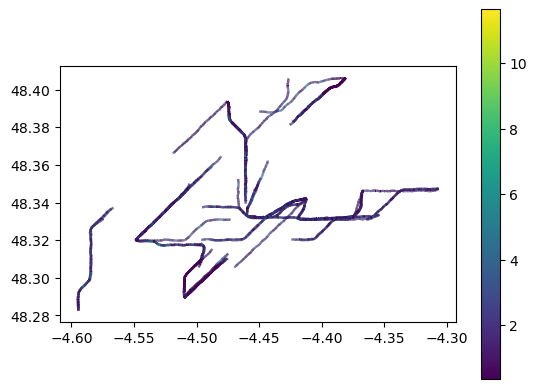

In [10]:
for i, traj in enumerate(tc.trajectories):
    if i in sample_ids_pd: 
        traj = inject_speed_anomaly(traj)
        tc.trajectories[i] = traj
    
tc.add_speed(overwrite=True)
tc.plot(column='speed', legend=True)

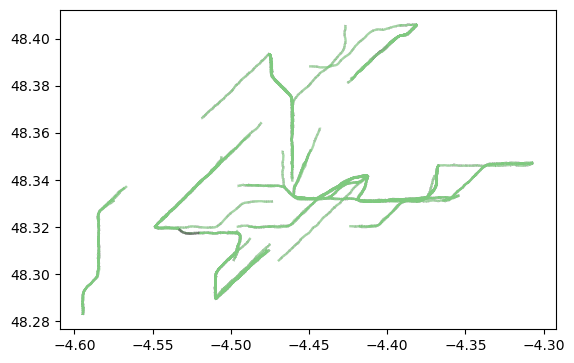

In [12]:
ax = tc.plot(column='is_anomaly', cmap='Accent')

In [13]:
try:
    tc.trajectories[0].hvplot(c='speed')
except:
    pass

In [14]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_speed_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulated speed anomalies to {sim_out_file_name}')

Saved simulated speed anomalies to anomalies_speed_20250909_095300.csv


### Location

#### Generate trajectories that pass through obstacles

Note that is not guaranteed that each resulting trajectory will pass through an obtacle! Ships simply ignore the obstacles.

In [16]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=int(config["num_ships"]*2*PERCENTAGE_OF_ANOMALIES), # doubling the number, assuming that 50% will violate obstacles
        max_speed_range=config["max_speed_range"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=[config["obstacles"][0]], # Here we only select the first obstacle that describes the main land mass
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"],
        speed_variation=config.get("speed_variation", 0.1),           # 
        directional_variation=config.get("directional_variation", 5)  #
    )

In [17]:
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
print(f"{datetime.now()} Finished.")

2025-09-09 10:02:16.521295 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
Steps 400 - 449...
Steps 450 - 499...
Steps 500 - 549...
Steps 550 - 599...
Steps 600 - 649...
Steps 650 - 699...
Steps 700 - 749...
Steps 750 - 799...
Steps 800 - 849...
Steps 850 - 899...
Steps 900 - 949...
Steps 950 - 999...
Steps 1000 - 1049...
Steps 1050 - 1099...
Steps 1100 - 1149...
Steps 1150 - 1199...
Steps 1200 - 1249...
Steps 1250 - 1299...
Steps 1300 - 1349...
Steps 1350 - 1399...
Steps 1400 - 1449...
Steps 1450 - 1499...
Steps 1500 - 1549...
Steps 1550 - 1599...
Steps 1600 - 1649...
Steps 1650 - 1699...
Steps 1700 - 1749...
Steps 1750 - 1799...
Steps 1800 - 1849...
Steps 1850 - 1899...
Steps 1900 - 1949...
Steps 1950 - 1999...
Steps 2000 - 2049...
Steps 2050 - 2099...
Steps 2100 - 2149...
Steps 2150 - 2199...
Steps 2200 - 2249...
Steps 2250 - 2299...
Steps 2300 - 2349...
Steps 2350 - 2399.

In [18]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,103.794837,156.070802,"[(103, 156), (104, 156), (105, 156), (106, 156..."
1,0,1,10.920191,39.770506,"[(10, 39), (11, 39), (12, 39), (13, 39), (14, ..."
2,0,2,442.195175,425.289965,"[(442, 425), (441, 425), (440, 425), (439, 425..."
3,0,3,442.195175,425.289965,"[(442, 425), (441, 424), (440, 423), (439, 422..."
4,0,4,470.305509,238.523290,"[(470, 238), (469, 239), (468, 240), (467, 241..."
...,...,...,...,...,...
18000,3600,1,152.826363,125.741085,"[(10, 39), (11, 39), (12, 39), (13, 39), (14, ..."
18001,3600,2,326.590325,368.433610,"[(442, 425), (441, 425), (440, 425), (439, 425..."
18002,3600,3,358.874132,340.755525,"[(442, 425), (441, 424), (440, 423), (439, 422..."
18003,3600,4,382.537157,348.717391,"[(470, 238), (469, 239), (468, 240), (467, 241..."


Saved simulation plot to simulation_plot.png


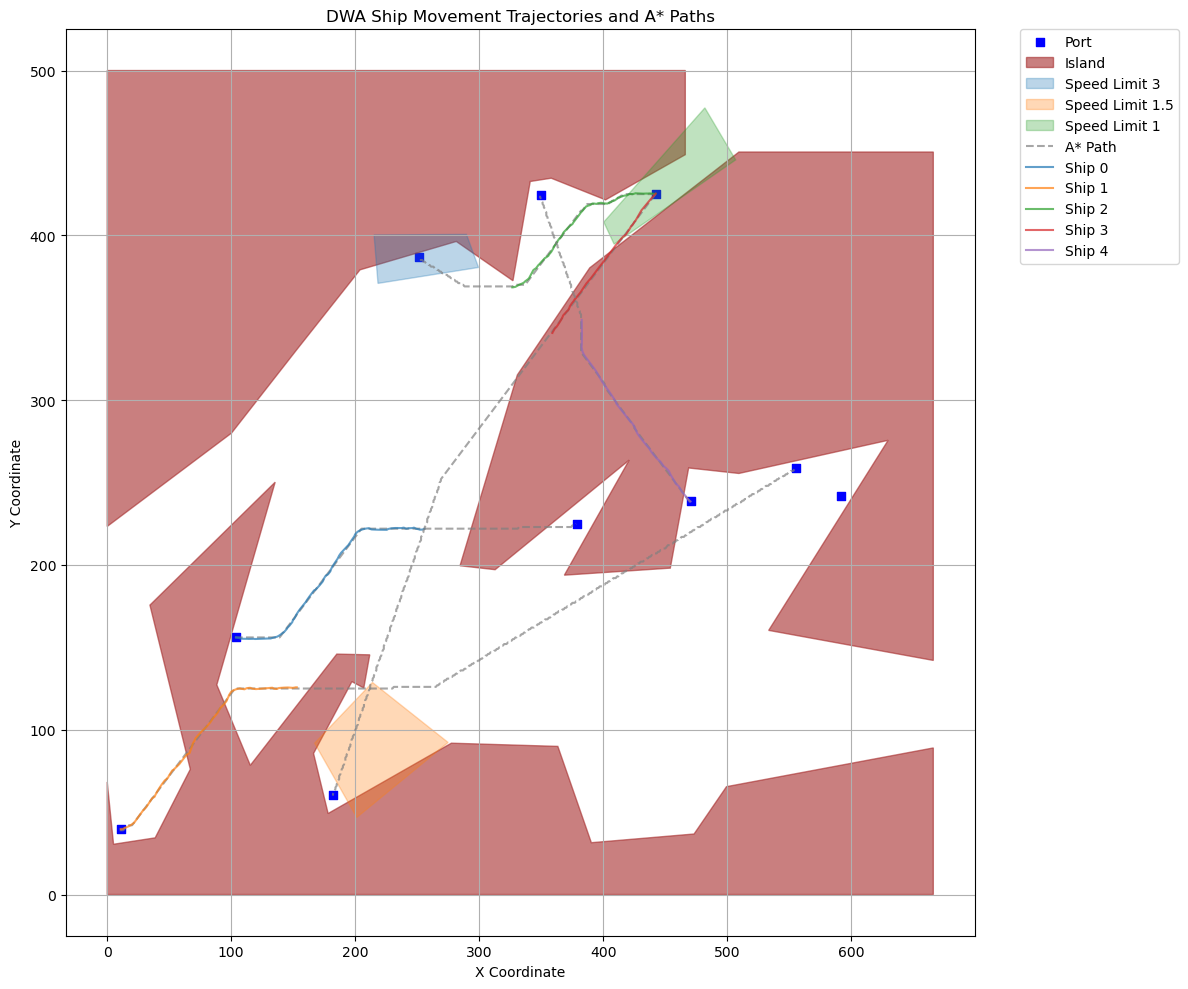

In [19]:
from visualization import plot_simulation
plot_simulation(df, config)

In [20]:
from datetime import datetime, timedelta
import movingpandas as mpd

# Nettoyage + temps
df = df.drop(columns=['AStarPath'], errors='ignore').copy()
start_datetime = datetime.now()
df["t"] = df["Step"].apply(lambda s: start_datetime + timedelta(seconds=int(s)))

# (optionnel) inverser l’axe Y si l’origine est en haut-gauche
# height = 500
# df["y"] = height - df["y"]

tc = mpd.TrajectoryCollection(
    df, traj_id_col='AgentID', t='t', x='x', y='y', crs=None
)


/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean dis

In [21]:
tc.add_speed(overwrite=True)
tc.trajectories[0].df

,Step,AgentID,geometry,speed
t,,,,
2025-09-09 10:08:19.662107,0,0,POINT (103.795 156.071),0.01000
2025-09-09 10:08:20.662107,1,0,POINT (103.804 156.068),0.01000
2025-09-09 10:08:21.662107,2,0,POINT (103.815 156.064),0.01100
2025-09-09 10:08:22.662107,3,0,POINT (103.826 156.061),0.01200
2025-09-09 10:08:23.662107,4,0,POINT (103.839 156.058),0.01300
...,...,...,...,...
2025-09-09 11:08:15.662107,3596,0,POINT (255.49 221.842),0.01886
2025-09-09 11:08:16.662107,3597,0,POINT (255.509 221.845),0.01986
2025-09-09 11:08:17.662107,3598,0,POINT (255.53 221.849),0.02086


In [27]:
min_lon, max_lon, min_lat, max_lat = -4.6, -4.27, 48.27, 48.43
#sim_result["lat"] = max_lat - (sim_result["y"] / (500)) * (min_lat - max_lat)
#sim_result["lon"] = min_lon + (sim_result["x"] / (666)) * (max_lon - min_lon)
sim_result["AgentID"]+=50
sim_result

,Step,AgentID,geometry,speed,x,y,lat,lon
t,,,,,,,,
2025-09-09 10:08:19.662107,0,50,POINT (103.795 156.071),0.010000,103.794837,156.070802,48.479943,-4.548570
2025-09-09 10:08:20.662107,1,50,POINT (103.804 156.068),0.010000,103.804290,156.067540,48.479942,-4.548565
2025-09-09 10:08:21.662107,2,50,POINT (103.815 156.064),0.011000,103.814779,156.064225,48.479941,-4.548560
2025-09-09 10:08:22.662107,3,50,POINT (103.826 156.061),0.012000,103.826311,156.060909,48.479939,-4.548555
2025-09-09 10:08:23.662107,4,50,POINT (103.839 156.058),0.013000,103.838895,156.057645,48.479938,-4.548548
...,...,...,...,...,...,...,...,...
2025-09-09 11:08:15.662107,3596,54,POINT (382.529 348.526),0.045289,382.528946,348.526458,48.541528,-4.410459
2025-09-09 11:08:16.662107,3597,54,POINT (382.529 348.573),0.046289,382.529399,348.572744,48.541543,-4.410458
2025-09-09 11:08:17.662107,3598,54,POINT (382.531 348.62),0.047289,382.531098,348.620002,48.541558,-4.410458


In [28]:
#sim_result = tc.to_point_gdf()
#sim_result['x'] = sim_result.geometry.x
#sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_no-obstacles_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')

Saved simulation results to sim_no-obstacles_20250909_101931.csv


#### Flag anomalies

In [110]:
sims = pd.read_csv("sim_no-obstacles_20250909_101931.csv")
sims

,t,Step,AgentID,geometry,speed,x,y,lat,lon
0,2025-09-09 10:08:19.662107,0,50,POINT (103.794837 156.070802),0.010000,103.794837,156.070802,48.479943,-4.548570
1,2025-09-09 10:08:20.662107,1,50,POINT (103.80428993239788 156.06753978157056),0.010000,103.804290,156.067540,48.479942,-4.548565
2,2025-09-09 10:08:21.662107,2,50,POINT (103.81477852923884 156.06422476478207),0.011000,103.814779,156.064225,48.479941,-4.548560
3,2025-09-09 10:08:22.662107,3,50,POINT (103.82631137980307 156.06090914148277),0.012000,103.826311,156.060909,48.479939,-4.548555
4,2025-09-09 10:08:23.662107,4,50,POINT (103.83889504553419 156.05764549984073),0.013000,103.838895,156.057645,48.479938,-4.548548
...,...,...,...,...,...,...,...,...,...
18000,2025-09-09 11:08:15.662107,3596,54,POINT (382.5289463394554 348.52645750737076),0.045289,382.528946,348.526458,48.541528,-4.410459
18001,2025-09-09 11:08:16.662107,3597,54,POINT (382.5293985859696 348.5727439154539),0.046289,382.529399,348.572744,48.541543,-4.410458
18002,2025-09-09 11:08:17.662107,3598,54,POINT (382.53109825691814 348.6200019777671),0.047289,382.531098,348.620002,48.541558,-4.410458
18003,2025-09-09 11:08:18.662107,3599,54,POINT (382.53409650750007 348.6681974242654),0.048289,382.534097,348.668197,48.541574,-4.410456


In [111]:
#sims = sims[sims.AgentID<22].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'
sims["geometry"] = [Point(xy) for xy in zip(sims["x"], sims["y"])]
#sims["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(sims, t='t', traj_id_col='AgentID', x='x', y='y', crs=None)
tc

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean dis

TrajectoryCollection with 5 trajectories

<Axes: >

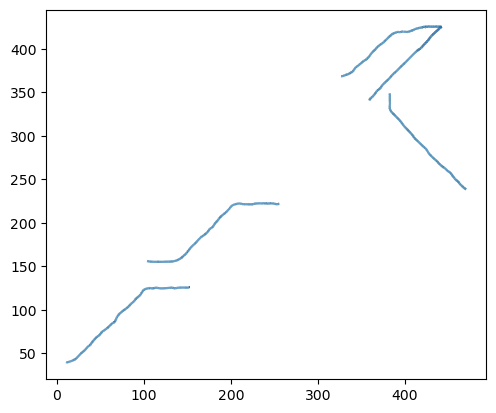

In [112]:
tc.plot(aspect="equal")

In [113]:
from shapely.geometry import Polygon
from geopandas import GeoSeries

def inject_location_anomaly(traj, polygon):
    sims = traj.df.copy()
    intersecting = sims.intersects(polygon)
    sims.loc[intersecting, 'is_anomaly'] = True
    sims.loc[intersecting, 'anomaly_type'] = 'location'
    return mpd.Trajectory(sims,t='t',traj_id=traj.id)

In [114]:

obstacles=config["obstacles"]
polygons=[]

for obstacle in obstacles:
    polygon = Polygon(obstacle)
    polygons.append(polygon)
    for i, traj in enumerate(tc.trajectories):
        traj = inject_location_anomaly(traj, polygon)
        tc.trajectories[i] = traj
    

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean distances.
  warnings.warn(
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/trajectory.py:186: MissingCRSWarning: Trajectory generated without CRS. Computations will use Euclidean dis

<Axes: >

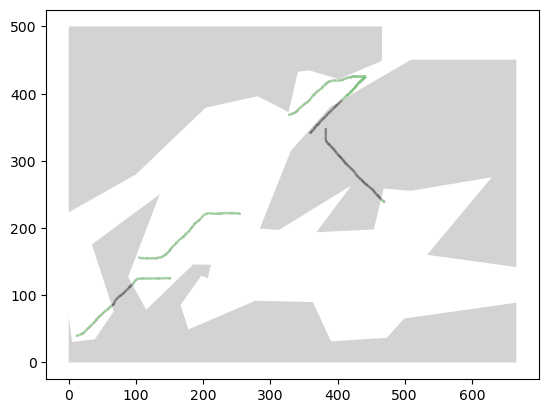

In [115]:
ax = tc.plot(column='is_anomaly', cmap='Accent', aspect="equal")
GeoSeries(polygons).plot(ax=ax, color="lightgray")

In [116]:
import geopandas as gpd
from shapely.geometry import Point

# --- paramètres de ta grille (à adapter si besoin) ---
width, height = 666, 500
min_lon, max_lon = -4.6, -4.27
min_lat, max_lat = 48.27, 48.43

'\n# (optionnel) sauvegarder la géométrie grille\nif "geometry" in df.columns:\n    df.rename(columns={"geometry": "geometry_grid"}, inplace=True)\n\n# mapping grille -> WGS84 (origine (0,0) en haut-gauche)\ndf["x"] = min_lon + (df["x"] / width)  * (max_lon - min_lon)\ndf["y"] = min_lat + (df["y"] / height) * (max_lat - min_lat)\n\n# nouvelle géométrie en degrés\ndf["geometry"] = gpd.points_from_xy(df["lon"], df["lat"])\ngdf = gpd.GeoDataFrame(df, geometry="geometry")  # GeoDataFrame sans fixer le CRS\n\n# Si pyproj/PROJ est OK et tu veux l’info CRS :\n# gdf.set_crs(epsg=4326, inplace=True)'

In [118]:
#df = df.drop(columns=['lat'])
#df.loc[df['is_anomaly']==True]
sims=tc.to_point_gdf()
sims

,Step,AgentID,geometry,speed,x,y,lat,lon,is_anomaly,anomaly_type,traj_id
t,,,,,,,,,,,
2025-09-09 10:08:19.662107,0,50,POINT (103.795 156.071),0.010000,103.794837,156.070802,48.479943,-4.548570,False,n/a,50
2025-09-09 10:08:20.662107,1,50,POINT (103.804 156.068),0.010000,103.804290,156.067540,48.479942,-4.548565,False,n/a,50
2025-09-09 10:08:21.662107,2,50,POINT (103.815 156.064),0.011000,103.814779,156.064225,48.479941,-4.548560,False,n/a,50
2025-09-09 10:08:22.662107,3,50,POINT (103.826 156.061),0.012000,103.826311,156.060909,48.479939,-4.548555,False,n/a,50
2025-09-09 10:08:23.662107,4,50,POINT (103.839 156.058),0.013000,103.838895,156.057645,48.479938,-4.548548,False,n/a,50
...,...,...,...,...,...,...,...,...,...,...,...
2025-09-09 11:08:15.662107,3596,54,POINT (382.529 348.526),0.045289,382.528946,348.526458,48.541528,-4.410459,True,location,54
2025-09-09 11:08:16.662107,3597,54,POINT (382.529 348.573),0.046289,382.529399,348.572744,48.541543,-4.410458,True,location,54
2025-09-09 11:08:17.662107,3598,54,POINT (382.531 348.62),0.047289,382.531098,348.620002,48.541558,-4.410458,True,location,54


In [119]:
sims=sims.drop(columns=['x'])
sims=sims.drop(columns=['y'])
sims["y"]=sims["lat"]
sims["x"]=sims["lon"]
sims=sims.drop(columns=['lat'])
sims=sims.drop(columns=['lon'])
sims

,Step,AgentID,geometry,speed,is_anomaly,anomaly_type,traj_id,y,x
t,,,,,,,,,
2025-09-09 10:08:19.662107,0,50,POINT (103.795 156.071),0.010000,False,n/a,50,48.479943,-4.548570
2025-09-09 10:08:20.662107,1,50,POINT (103.804 156.068),0.010000,False,n/a,50,48.479942,-4.548565
2025-09-09 10:08:21.662107,2,50,POINT (103.815 156.064),0.011000,False,n/a,50,48.479941,-4.548560
2025-09-09 10:08:22.662107,3,50,POINT (103.826 156.061),0.012000,False,n/a,50,48.479939,-4.548555
2025-09-09 10:08:23.662107,4,50,POINT (103.839 156.058),0.013000,False,n/a,50,48.479938,-4.548548
...,...,...,...,...,...,...,...,...,...
2025-09-09 11:08:15.662107,3596,54,POINT (382.529 348.526),0.045289,True,location,54,48.541528,-4.410459
2025-09-09 11:08:16.662107,3597,54,POINT (382.529 348.573),0.046289,True,location,54,48.541543,-4.410458
2025-09-09 11:08:17.662107,3598,54,POINT (382.531 348.62),0.047289,True,location,54,48.541558,-4.410458


In [120]:
#df = tc.to_point_gdf()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_loc_{timestamp}.csv'
sims.to_csv(sim_out_file_name)
print(f'Saved simulated location anomalies to {sim_out_file_name}')
#sims

Saved simulated location anomalies to anomalies_loc_20250909_110151.csv


### Direction

TODO

## Merge files

In [121]:
df1 = pd.read_csv("anomalies_speed_20250909_095300.csv")
df2 = pd.read_csv("anomalies_loc_20250909_110151.csv")
out = pd.concat([df1,df2])[['t','AgentID','speed','is_anomaly','anomaly_type','x','y']]
out.to_csv("synthetic_vessel_tracks_with_anomalies_20250909.csv", index=False)

/tmp/ipykernel_13773/3556536279.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("anomalies_speed_20250909_095300.csv")


In [125]:
tmp = pd.read_csv("synthetic_vessel_tracks_with_anomalies_20250909.csv")
tmp["speed"] = pd.to_numeric(tmp["speed"], errors="coerce") *  1.943844492 #vitesse en noeuds
tmp

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
0,2025-09-04 15:40:23.865360,0,0.705961,False,NaN,-4.366966,48.346327
1,2025-09-04 15:40:24.865360,0,0.705961,False,NaN,-4.366962,48.346326
2,2025-09-04 15:40:25.865360,0,0.777763,False,NaN,-4.366957,48.346324
3,2025-09-04 15:40:26.865360,0,0.849106,False,NaN,-4.366952,48.346321
4,2025-09-04 15:40:27.865360,0,0.920538,False,NaN,-4.366947,48.346319
...,...,...,...,...,...,...,...
198050,2025-09-09 11:08:15.662107,54,0.088034,True,location,-4.410459,48.541528
198051,2025-09-09 11:08:16.662107,54,0.089978,True,location,-4.410458,48.541543
198052,2025-09-09 11:08:17.662107,54,0.091922,True,location,-4.410458,48.541558
198053,2025-09-09 11:08:18.662107,54,0.093866,True,location,-4.410456,48.541574


In [126]:
tmp[tmp.anomaly_type=="location"]

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
185073,2025-09-09 10:32:01.662107,51,0.133111,True,location,-4.568213,48.457155
185074,2025-09-09 10:32:02.662107,51,0.135055,True,location,-4.568182,48.457166
185075,2025-09-09 10:32:03.662107,51,0.136999,True,location,-4.568151,48.457176
185076,2025-09-09 10:32:04.662107,51,0.138943,True,location,-4.568119,48.457186
185077,2025-09-09 10:32:05.662107,51,0.140887,True,location,-4.568086,48.457195
...,...,...,...,...,...,...,...
198050,2025-09-09 11:08:15.662107,54,0.088034,True,location,-4.410459,48.541528
198051,2025-09-09 11:08:16.662107,54,0.089978,True,location,-4.410458,48.541543
198052,2025-09-09 11:08:17.662107,54,0.091922,True,location,-4.410458,48.541558
198053,2025-09-09 11:08:18.662107,54,0.093866,True,location,-4.410456,48.541574


In [127]:
tmp[tmp.anomaly_type=="location"].AgentID.unique()

array([51, 53, 54])